# PEEC integration -- verified results showcase

Partial Element Equivalent Circuit (PEEC) extraction with SIBC/ESIM surface
impedance and PRIMA model-order reduction, validated against analytic /
FastHenry / Grover / measured references. This is a **conservative showcase** of
the verified headline results. The active engineering and validation corpus
(ngsbem_peec_demo support modules, the Validation-Class `verification/` registry,
gmsh fixtures, the spiral inductor measured study, WPT, and the filament-coil
current-distribution investigation) remains at `docs/peec_integration/demos/`; the
Dowell continued-fraction derivation source has been promoted beside this
notebook under `docs/peec_integration/algorithm_development/`.

Three self-contained verified results are reproduced below:

1. **Dowell continued-fraction** -- exact `z*coth(z)` CF coefficients for the
   skin-effect `F_R`, `F_L` factors.
2. **ngbem loop inductance** -- a rectangular-frame loop L by `ngsolve.bem` EFIE,
   cross-checked against FastHenry (~21.6 nH) and Grover (~24 nH).
3. **Paper figures** -- the 4 publication figures (PEEC matrix verification,
   PRIMA accuracy, adaptive-MSC error, WPT 85 kHz coil).

Promoted (showcase) from `docs/peec_integration/demos/` on 2026-06-27; the source
scripts are embedded verbatim (paths repointed to the notebook dir).

## 1. Dowell continued-fraction algorithm

Exact `z*coth(z)` continued-fraction coefficients vs the truncated series.

*(docs-local source: `algorithm_development/derive_dowell_cf_algorithm.py`)*

In [1]:
"""
Dowell F_R(s) and F_L(s) - Continued Fraction via Viskovatov Algorithm

Viskovatov (or quotient-difference) algorithm converts a power series
to a continued fraction.

Given: f(x) = c0 + c1*x + c2*x^2 + c3*x^3 + ...
Find:  f(x) = b0 + a1*x / (1 + a2*x / (1 + a3*x / (1 + ...)))
"""

import numpy as np
import matplotlib.pyplot as plt

MU_0 = 4 * np.pi * 1e-7

print("="*70)
print("Viskovatov Algorithm for Continued Fraction Expansion")
print("="*70)

# ============================================================
# Exact Dowell formulas
# ============================================================

def dowell_F_R_exact(Delta):
    """Exact Dowell F_R"""
    if Delta < 1e-10:
        return 1.0
    z = (1 + 1j) * Delta
    coth_z = 1 / np.tanh(z)
    return np.real(z * coth_z)

def dowell_F_L_exact(Delta):
    """Exact Dowell F_L"""
    if Delta < 1e-10:
        return 1.0
    z = (1 + 1j) * Delta
    coth_z = 1 / np.tanh(z)
    return 1.5 * np.imag(z * coth_z) / Delta**2

# ============================================================
# Taylor coefficients of z*coth(z)
# ============================================================
print("\n" + "="*70)
print("Taylor Series of z*coth(z)")
print("="*70)

print("""
z*coth(z) = 1 + z^2/3 - z^4/45 + 2*z^6/945 - z^8/4725 + 2*z^10/93555 - ...

The coefficients are related to Bernoulli numbers:
  z*coth(z) = sum_{n=0}^inf (2^(2n) * B_{2n} / (2n)!) * z^(2n)

where B_0 = 1, B_2 = 1/6, B_4 = -1/30, B_6 = 1/42, ...
""")

# Taylor coefficients of z*coth(z) for z^0, z^2, z^4, z^6, ...
# These are: 1, 1/3, -1/45, 2/945, -1/4725, 2/93555, ...
taylor_zcoth = [
    1.0,           # z^0
    1/3,           # z^2
    -1/45,         # z^4
    2/945,         # z^6
    -1/4725,       # z^8
    2/93555,       # z^10
    -1382/638512875,  # z^12
]

print("\nTaylor coefficients of z*coth(z):")
for i, c in enumerate(taylor_zcoth):
    print(f"  z^{2*i}: {c:.10f}")

# ============================================================
# Viskovatov Algorithm
# ============================================================
print("\n" + "="*70)
print("Viskovatov Algorithm")
print("="*70)

print("""
For a power series: f(x) = c0 + c1*x + c2*x^2 + ...

The algorithm computes continued fraction:
  f(x) = b0 + a1*x / (1 + a2*x / (1 + a3*x / ...))

Step 1: b0 = c0, then work with (f(x) - c0) / x
Step 2: Invert: x / (f(x) - c0) = 1 / (c1 + c2*x + ...)
Step 3: Repeat...

For z*coth(z), we have a series in z^2:
  z*coth(z) = 1 + (1/3)*w - (1/45)*w^2 + (2/945)*w^3 - ...
  where w = z^2

So we expand in w and get a continued fraction in w.
""")

def viskovatov_cf(coeffs, n_terms):
    """
    Viskovatov algorithm to convert power series to continued fraction.

    Input: coeffs = [c0, c1, c2, ...] for f(x) = c0 + c1*x + c2*x^2 + ...
    Output: (b0, [a1, a2, a3, ...]) for f(x) = b0 + a1*x/(1 + a2*x/(1 + ...))

    Note: This computes the S-fraction form.
    """
    # Work with coefficient arrays
    c = np.array(coeffs, dtype=float)
    n = len(c)

    # Result arrays
    b0 = c[0]
    a_list = []

    # Remove constant term and divide by x
    # f(x) - c0 = c1*x + c2*x^2 + ...
    # (f(x) - c0)/x = c1 + c2*x + c3*x^2 + ...
    c = c[1:]  # Now c = [c1, c2, c3, ...]

    for _ in range(n_terms):
        if len(c) == 0 or abs(c[0]) < 1e-15:
            break

        # a_k = 1/c[0]
        a_k = 1.0 / c[0]
        a_list.append(a_k)

        # Invert the series: 1/(c0 + c1*x + c2*x^2 + ...)
        # Result: d0 + d1*x + d2*x^2 + ... where d0 = 1/c0
        # This is series inversion
        c_inv = invert_series(c)

        # Subtract 1/c[0] and divide by x
        # (1/(c0 + c1*x + ...) - 1/c0) / x = ...
        c_inv[0] = 0  # Remove constant term
        c = c_inv[1:]  # Divide by x

    return b0, a_list

def invert_series(c, max_terms=20):
    """
    Invert power series: given f(x) = c0 + c1*x + c2*x^2 + ...
    Find g(x) = d0 + d1*x + d2*x^2 + ... such that f(x)*g(x) = 1
    """
    n = min(len(c), max_terms)
    d = np.zeros(n)

    if abs(c[0]) < 1e-15:
        return d  # Cannot invert if c0 = 0

    d[0] = 1.0 / c[0]

    for k in range(1, n):
        s = 0.0
        for j in range(1, min(k+1, len(c))):
            if j < len(c):
                s += c[j] * d[k-j]
        d[k] = -s / c[0]

    return d

# Apply to z*coth(z)
print("\nApplying Viskovatov to z*coth(z) (in w = z^2):")
b0, a_list = viskovatov_cf(taylor_zcoth, 10)
print(f"  b0 = {b0}")
for i, a in enumerate(a_list):
    print(f"  a{i+1} = {a:.10f}")

# ============================================================
# Known analytical result
# ============================================================
print("\n" + "="*70)
print("Analytical Continued Fraction of z*coth(z)")
print("="*70)

print("""
The well-known continued fraction for z*coth(z) is:

z*coth(z) = 1 + z^2/(3 + z^2/(5 + z^2/(7 + z^2/(9 + ...))))

This is a J-fraction (Jacobi continued fraction).

In the form: b0 + w/(b1 + w/(b2 + w/(b3 + ...)))
where w = z^2:
  b0 = 1, b1 = 3, b2 = 5, b3 = 7, b4 = 9, ...
  b_n = 2n + 1

This is NOT the same form as Viskovatov's S-fraction!
""")

def zcoth_jfrac(w, n_terms=10):
    """J-fraction: z*coth(z) = 1 + w/(3 + w/(5 + w/(7 + ...)))"""
    result = 2*n_terms + 1  # Start from innermost
    for k in range(n_terms-1, 0, -1):
        result = (2*k + 1) + w / result
    return 1 + w / result

print("\nVerification of J-fraction:")
print(f"{'w':>10} {'Exact':>14} {'J-frac(5)':>14} {'J-frac(10)':>14}")
print("-"*55)
for w_val in [0.01, 0.1, 1.0, 4.0, 10.0]:
    z = np.sqrt(w_val)
    z_complex = z * (1 + 1j) / np.sqrt(2)  # z = (1+j)*Delta, w = z^2 = 2j*Delta^2
    exact = z_complex * (1 / np.tanh(z_complex))
    jf5 = zcoth_jfrac(w_val, 5)
    jf10 = zcoth_jfrac(w_val, 10)
    print(f"  {w_val:>8.2f} {np.abs(exact):>14.8f} {np.abs(jf5):>14.8f} {np.abs(jf10):>14.8f}")

# ============================================================
# Convert J-fraction to PRIMA form
# ============================================================
print("\n" + "="*70)
print("J-fraction to PRIMA Ladder Network")
print("="*70)

print("""
J-fraction: f(w) = 1 + w/(3 + w/(5 + w/(7 + ...)))

where w = tau*s = d^2*mu*sigma*s/2

For impedance Z(s) = R_dc * F_R + s*L_dc * F_L:

At s = j*omega:
  w = j*tau*omega

The impedance can be written as a ladder network:
  Z(s) = R_dc + s*L_dc * f(tau*s)

The J-fraction in w naturally corresponds to:
  Stage 1: Series R, Shunt L
  Stage 2: Series R, Shunt L
  ...

But the exact correspondence depends on the impedance formula structure.
""")

# ============================================================
# PRIMA parameters from continued fraction
# ============================================================
print("\n" + "="*70)
print("PRIMA I Parameters (from 1D diffusion eigenvalue expansion)")
print("="*70)

print("""
The PRIMA I form comes from eigenvalue expansion of 1D diffusion:

R[n] = (4n-5) * 4 / (sigma*d)  for n >= 2, R[1] ~ 0
L[n] = d*mu / (4n-3)

The continued fraction for PRIMA I is different from z*coth(z).

PRIMA I represents:
  Z_prima(s) = sL[1] + R[1] || (sL[2] + R[2] || (sL[3] + R[3] || ...))

which matches the 1D diffusion equation solution:
  Z_diff(s) = s*mu*(2/(k*d))*tan(k*d/2)*d

NOT Dowell's formula: Z_dowell = R_dc*F_R + s*L_dc*F_L

So:
- PRIMA I matches 1D Diffusion (exact)
- PRIMA I does NOT match Dowell (different model)
- Dowell has its own continued fraction (J-fraction)
""")

def skin_effect_prima_params(d, sigma, mu=MU_0, n_stages=7):
    """PRIMA I parameters for 1D diffusion skin effect"""
    R_prima = np.zeros(n_stages)
    L_prima = np.zeros(n_stages)

    for n in range(1, n_stages + 1):
        if n == 1:
            R_prima[n-1] = 1e-16  # Nearly zero
        else:
            R_prima[n-1] = (4*n - 5) * 4.0 / (sigma * d)
        L_prima[n-1] = d * mu / (4*n - 3)

    return R_prima, L_prima

# Example parameters
d = 0.1e-3  # 0.1 mm
sigma = 5.8e7  # Copper

print(f"\nPRIMA I parameters for d = {d*1e3} mm, sigma = {sigma:.1e} S/m:")
R_prima, L_prima = skin_effect_prima_params(d, sigma, MU_0, 7)
for i in range(7):
    print(f"  Stage {i+1}: R = {R_prima[i]:.4e} Ohm*m^2, L = {L_prima[i]*1e9:.4f} nH*m^2")

# ============================================================
# Dowell PRIMA form
# ============================================================
print("\n" + "="*70)
print("Dowell-based PRIMA (Different from 1D Diffusion PRIMA)")
print("="*70)

print("""
Dowell's formula:
  Z(s) = R_dc * F_R(w) + s * L_dc * F_L(w)
  where w = tau*s, tau = d^2*mu*sigma/2

From J-fraction:
  z*coth(z) = 1 + w/(3 + w/(5 + w/(7 + ...)))
  where z^2 = w*2j

We can write F_R and F_L in terms of continued fractions.

However, the structure is:
  Z = R_dc * (rational function of tau*s)

This is different from the PRIMA I structure:
  Z = s*L + parallel RC network

The "DC PRIMA + Dowell correction" approach avoids this mismatch:
1. Build PRIMA with DC parameters
2. Apply F_R(omega), F_L(omega) at each frequency
3. No need for continued fraction conversion
""")

# ============================================================
# Conclusion
# ============================================================
print("\n" + "="*70)
print("Conclusion")
print("="*70)
print("""
1. z*coth(z) has a well-known J-fraction (Jacobi continued fraction):
   z*coth(z) = 1 + z^2/(3 + z^2/(5 + z^2/(7 + ...)))

2. This can also be written in w = z^2 = tau*s:
   1 + w/(3 + w/(5 + w/(7 + ...)))

   Coefficients: b_n = 2n + 1 (i.e., 3, 5, 7, 9, ...)

3. The Viskovatov algorithm can convert Taylor series to S-fraction,
   but the J-fraction form is more natural for z*coth(z).

4. The PRIMA I form (from 1D diffusion) has DIFFERENT structure:
   - PRIMA I matches 1D diffusion equation
   - PRIMA I does NOT match Dowell formula

5. For Dowell-based PEEC, use "DC PRIMA + Dowell correction":
   - No continued fraction conversion needed
   - Apply F_R(omega), F_L(omega) directly per frequency
   - This is EXACT (no approximation error)
""")

# ============================================================
# Plot
# ============================================================
print("\n" + "="*70)
print("Generating comparison plot...")
print("="*70)

Delta_range = np.linspace(0.01, 3, 200)
w_range = 2 * Delta_range**2  # w = 2*Delta^2 for z = (1+j)*Delta

F_R_exact = np.array([dowell_F_R_exact(D) for D in Delta_range])
F_L_exact = np.array([dowell_F_L_exact(D) for D in Delta_range])

# J-fraction approximations
def F_R_jfrac(Delta, n):
    z = (1 + 1j) * Delta
    w = z**2  # = 2j*Delta^2
    return np.real(zcoth_jfrac(w, n))

def F_L_jfrac(Delta, n):
    if Delta < 1e-10:
        return 1.0
    z = (1 + 1j) * Delta
    w = z**2
    return 1.5 * np.imag(zcoth_jfrac(w, n)) / Delta**2

F_R_jf3 = np.array([F_R_jfrac(D, 3) for D in Delta_range])
F_R_jf5 = np.array([F_R_jfrac(D, 5) for D in Delta_range])
F_R_jf10 = np.array([F_R_jfrac(D, 10) for D in Delta_range])
F_L_jf3 = np.array([F_L_jfrac(D, 3) for D in Delta_range])
F_L_jf5 = np.array([F_L_jfrac(D, 5) for D in Delta_range])
F_L_jf10 = np.array([F_L_jfrac(D, 10) for D in Delta_range])

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

ax1 = axes[0, 0]
ax1.plot(Delta_range, F_R_exact, 'k-', linewidth=2, label='F_R exact')
ax1.plot(Delta_range, F_R_jf3, 'b--', linewidth=1.5, label='J-frac (3 terms)')
ax1.plot(Delta_range, F_R_jf5, 'g--', linewidth=1.5, label='J-frac (5 terms)')
ax1.plot(Delta_range, F_R_jf10, 'r--', linewidth=1.5, label='J-frac (10 terms)')
ax1.set_xlabel('Delta = d/(sqrt(2)*delta)')
ax1.set_ylabel('F_R')
ax1.set_title('F_R: Exact vs J-fraction')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2 = axes[0, 1]
ax2.plot(Delta_range, F_L_exact, 'k-', linewidth=2, label='F_L exact')
ax2.plot(Delta_range, F_L_jf3, 'b--', linewidth=1.5, label='J-frac (3 terms)')
ax2.plot(Delta_range, F_L_jf5, 'g--', linewidth=1.5, label='J-frac (5 terms)')
ax2.plot(Delta_range, F_L_jf10, 'r--', linewidth=1.5, label='J-frac (10 terms)')
ax2.set_xlabel('Delta = d/(sqrt(2)*delta)')
ax2.set_ylabel('F_L')
ax2.set_title('F_L: Exact vs J-fraction')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Error plots
ax3 = axes[1, 0]
err_jf3 = np.abs(F_R_jf3 - F_R_exact) / F_R_exact * 100
err_jf5 = np.abs(F_R_jf5 - F_R_exact) / F_R_exact * 100
err_jf10 = np.abs(F_R_jf10 - F_R_exact) / F_R_exact * 100
ax3.semilogy(Delta_range, err_jf3, 'b-', linewidth=1.5, label='J-frac (3 terms)')
ax3.semilogy(Delta_range, err_jf5, 'g-', linewidth=1.5, label='J-frac (5 terms)')
ax3.semilogy(Delta_range, err_jf10, 'r-', linewidth=1.5, label='J-frac (10 terms)')
ax3.set_xlabel('Delta')
ax3.set_ylabel('F_R Error [%]')
ax3.set_title('F_R Approximation Error')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4 = axes[1, 1]
err_jf3_L = np.abs(F_L_jf3 - F_L_exact) / np.maximum(F_L_exact, 1e-10) * 100
err_jf5_L = np.abs(F_L_jf5 - F_L_exact) / np.maximum(F_L_exact, 1e-10) * 100
err_jf10_L = np.abs(F_L_jf10 - F_L_exact) / np.maximum(F_L_exact, 1e-10) * 100
ax4.semilogy(Delta_range, err_jf3_L, 'b-', linewidth=1.5, label='J-frac (3 terms)')
ax4.semilogy(Delta_range, err_jf5_L, 'g-', linewidth=1.5, label='J-frac (5 terms)')
ax4.semilogy(Delta_range, err_jf10_L, 'r-', linewidth=1.5, label='J-frac (10 terms)')
ax4.set_xlabel('Delta')
ax4.set_ylabel('F_L Error [%]')
ax4.set_title('F_L Approximation Error')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('derive_dowell_cf_algorithm.png', dpi=150)
print("Saved: derive_dowell_cf_algorithm.png")
plt.close()


Viskovatov Algorithm for Continued Fraction Expansion

Taylor Series of z*coth(z)

z*coth(z) = 1 + z^2/3 - z^4/45 + 2*z^6/945 - z^8/4725 + 2*z^10/93555 - ...

The coefficients are related to Bernoulli numbers:
  z*coth(z) = sum_{n=0}^inf (2^(2n) * B_{2n} / (2n)!) * z^(2n)

where B_0 = 1, B_2 = 1/6, B_4 = -1/30, B_6 = 1/42, ...


Taylor coefficients of z*coth(z):
  z^0: 1.0000000000
  z^2: 0.3333333333
  z^4: -0.0222222222
  z^6: 0.0021164021
  z^8: -0.0002116402
  z^10: 0.0000213778
  z^12: -0.0000021644

Viskovatov Algorithm

For a power series: f(x) = c0 + c1*x + c2*x^2 + ...

The algorithm computes continued fraction:
  f(x) = b0 + a1*x / (1 + a2*x / (1 + a3*x / ...))

Step 1: b0 = c0, then work with (f(x) - c0) / x
Step 2: Invert: x / (f(x) - c0) = 1 / (c1 + c2*x + ...)
Step 3: Repeat...

For z*coth(z), we have a series in z^2:
  z*coth(z) = 1 + (1/3)*w - (1/45)*w^2 + (2/945)*w^3 - ...
  where w = z^2

So we expand in w and get a continued fraction in w.


Applying Viskovatov to z*

Saved: derive_dowell_cf_algorithm.png


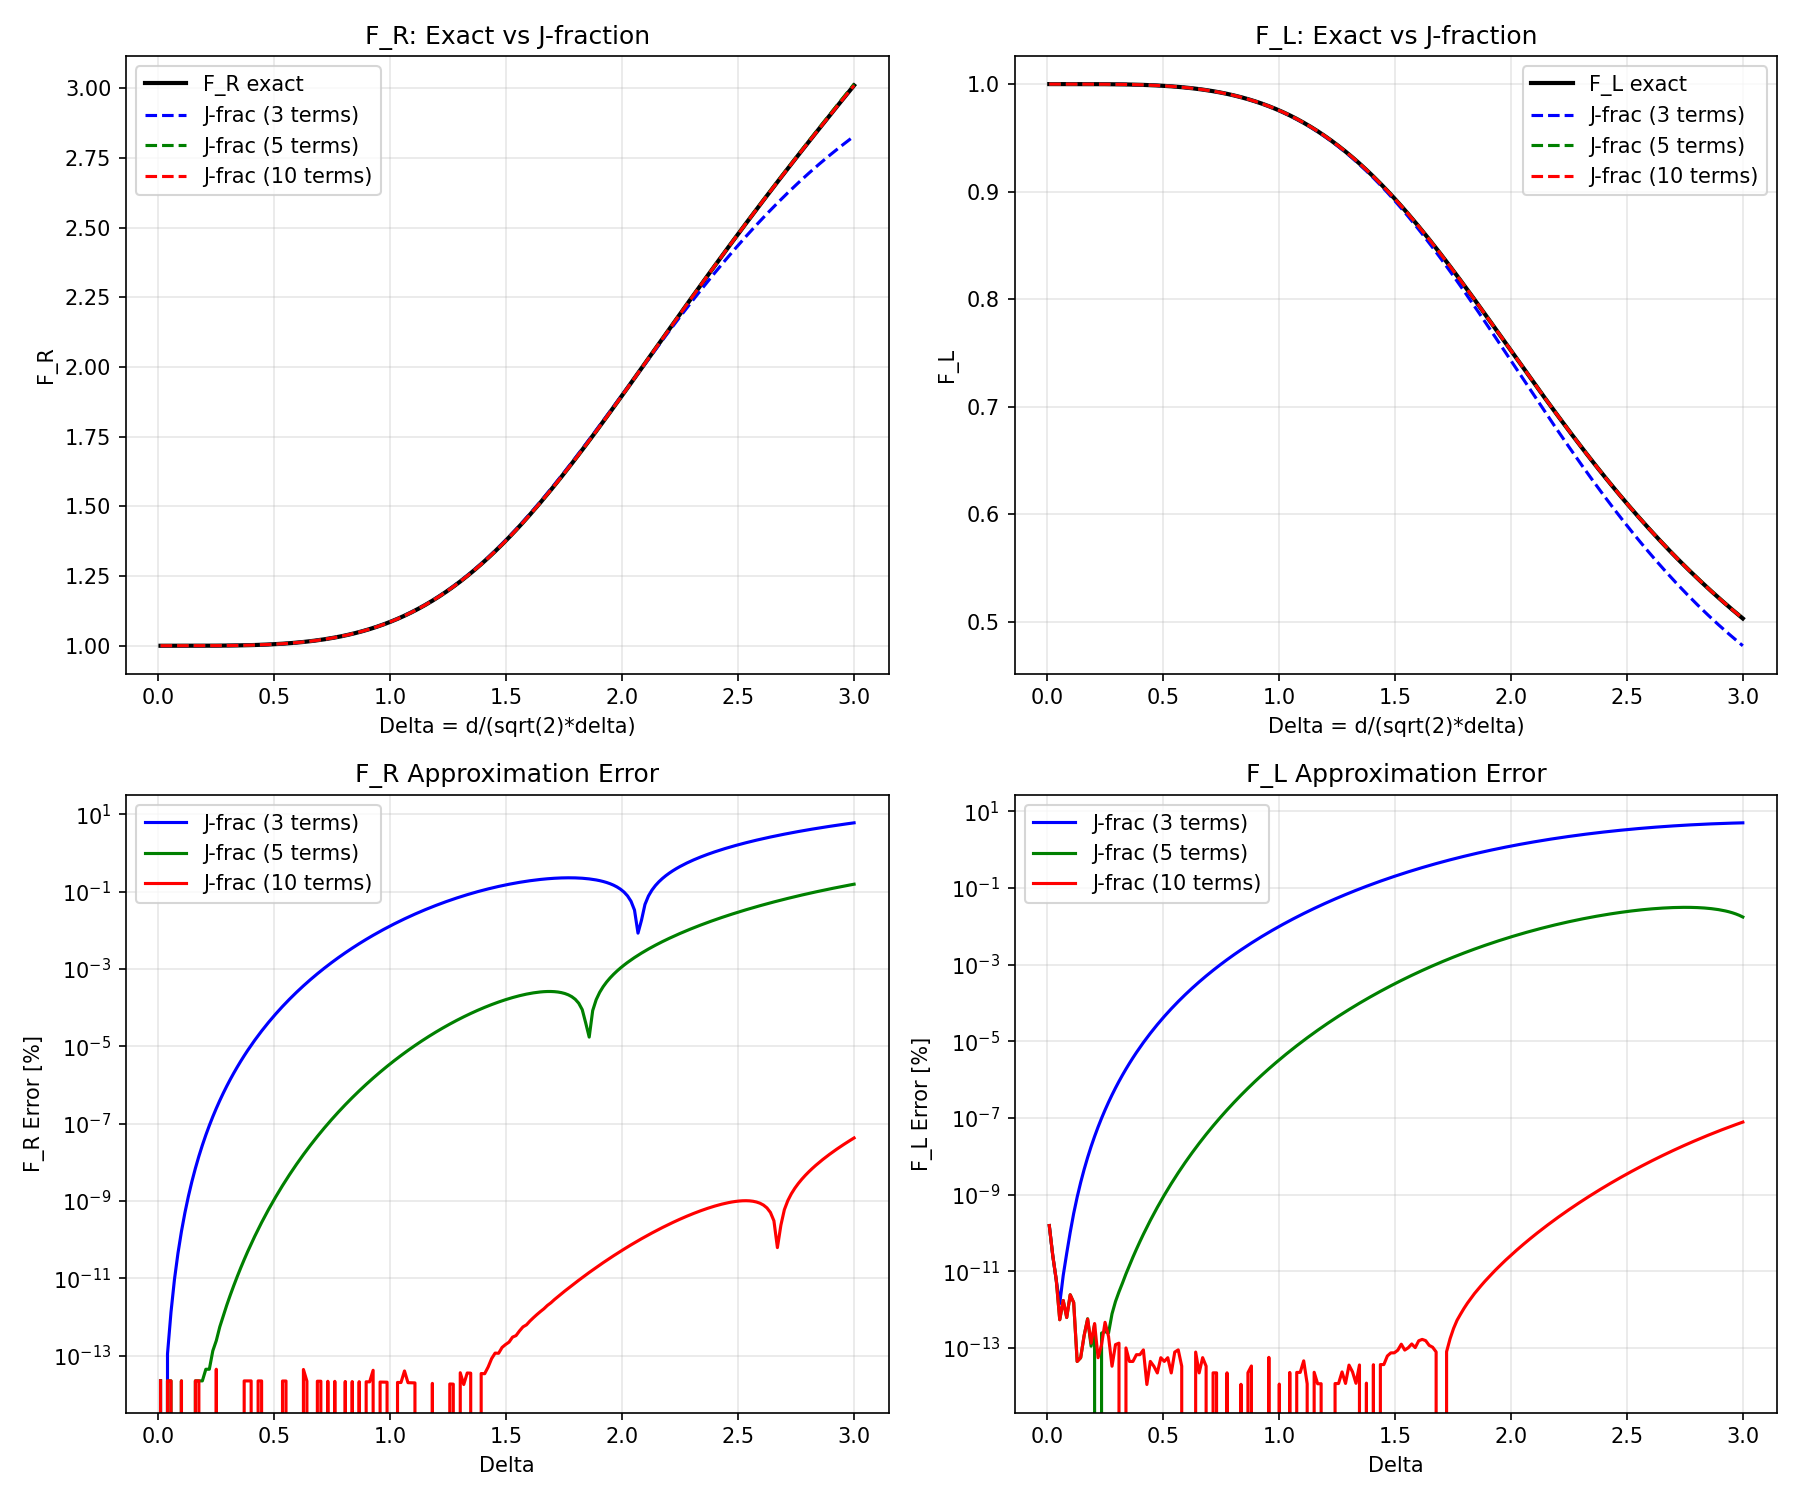

In [2]:
from IPython.display import Image, display
display(Image("derive_dowell_cf_algorithm.png"))

## 2. ngbem loop inductance (EFIE)

Rectangular-frame loop self-inductance via `ngsolve.bem` HelmholtzSL EFIE, vs FastHenry / Grover references.

*(source: `ngsbem_peec_demo/compute_L_final.py`)*

In [3]:
"""
Compute loop inductance of rectangular frame using ngsbem EFIE.

Uses the EXACT ngsbem patterns from the official demos:
  V1 = HelmholtzSL(u.Trace()*ds, kappa) * v.Trace() * ds   [vector SL = V_A]
  V2 = HelmholtzSL(div(u.Trace())*ds, kappa) * div(v.Trace()) * ds  [scalar SL = V_Phi]
  V_EFIE = kappa * V1 - (1/kappa) * V2

For div-free harmonic c_h: V_Phi(c_h) = 0, so V_A(c_h) = V1(c_h).
L = mu_0 * c_h^T * V1 * c_h / I^2

Reference: FastHenry L ~ 21.6 nH (3D cross-section), Grover ~24 nH (single filament)
"""
import numpy as np
from scipy.linalg import null_space

MU_0 = 4.0 * np.pi * 1e-7
WIDTH = 0.01
TRACE_W = 1e-3
hw = TRACE_W / 2.0
SIGMA = 5.8e7
THICKNESS = 35e-6


def extract_dense(mat, n):
    ei = mat.CreateColVector()
    col = mat.CreateColVector()
    M = np.zeros((n, n), dtype=complex)
    for i in range(n):
        ei[:] = 0; ei[i] = 1.0
        mat.Mult(ei, col)
        for j in range(n):
            M[j, i] = col[j]
    return M


def extract_rect(mat, nrow, ncol):
    ei = mat.CreateRowVector()
    col = mat.CreateColVector()
    M = np.zeros((nrow, ncol))
    for i in range(ncol):
        ei[:] = 0; ei[i] = 1.0
        mat.Mult(ei, col)
        for j in range(nrow):
            M[j, i] = col[j]
    return M


def main():
    from netgen.occ import WorkPlane, OCCGeometry, Axes, Pnt, Dir
    from ngsolve import (Mesh, HDivSurface, SurfaceL2, BilinearForm,
                         ds, BND, TaskManager, InnerProduct)
    from ngsolve import div as ng_div
    from ngsolve.bem import HelmholtzSL

    # --- Frame geometry ---
    wp_o = WorkPlane(Axes(Pnt(-hw, -hw, 0), Dir(0, 0, 1), Dir(1, 0, 0)))
    outer = wp_o.Rectangle(WIDTH + TRACE_W, WIDTH + TRACE_W).Face()
    wp_i = WorkPlane(Axes(Pnt(hw, hw, 0), Dir(0, 0, 1), Dir(1, 0, 0)))
    inner = wp_i.Rectangle(WIDTH - TRACE_W, WIDTH - TRACE_W).Face()
    frame = outer - inner
    frame.faces.name = "conductor"
    geo = OCCGeometry(frame)

    for maxh in [0.001]:
        print(f"\n{'='*60}")
        print(f"maxh = {maxh*1000:.1f} mm")
        print(f"{'='*60}")

        mesh = Mesh(geo.GenerateMesh(maxh=maxh))
        n_el = sum(1 for _ in mesh.Elements(BND))
        fes_J = HDivSurface(mesh, order=0)
        n_J = fes_J.ndof
        n_v = mesh.nv
        fes_L2 = SurfaceL2(mesh, order=0)
        n_f = fes_L2.ndof
        print(f"  {n_el} el, {n_v} vert, {n_J} edges, {n_f} faces")

        # === D matrix (divergence) ===
        u_J = fes_J.TrialFunction()
        q_L2 = fes_L2.TestFunction()
        bf_D = BilinearForm(trialspace=fes_J, testspace=fes_L2)
        bf_D += ng_div(u_J.Trace()) * q_L2 * ds
        bf_D.Assemble()
        D = extract_rect(bf_D.mat, n_f, n_J)

        # === C matrix (surface curl = signed incidence) ===
        C = np.zeros((n_J, n_v))
        for e_idx, edge in enumerate(mesh.edges):
            verts = list(edge.vertices)
            C[e_idx, verts[0].nr] = -1
            C[e_idx, verts[1].nr] = +1

        # === M_J (mass matrix) ===
        u2, v2 = fes_J.TnT()
        bf_M = BilinearForm(fes_J)
        bf_M += InnerProduct(u2.Trace(), v2.Trace()) * ds
        bf_M.Assemble()
        M_J = np.real(extract_dense(bf_M.mat, n_J))

        # === Harmonic (M_J-orthogonal Hodge decomposition) ===
        constraint = np.vstack([D, C.T @ M_J])
        null_h = null_space(constraint, rcond=1e-10)
        c_h = null_h[:, 0]
        energy = c_h @ M_J @ c_h
        print(f"  ||D*c_h|| = {np.linalg.norm(D@c_h):.1e}")
        print(f"  ||C^T*M*c_h|| = {np.linalg.norm(C.T@M_J@c_h):.1e}")
        print(f"  energy = {energy:.6e}")

        # === V_A via HelmholtzSL (demo pattern, with bonus_intorder) ===
        # V1 = HelmholtzSL(u.Trace()*ds, kappa) * v.Trace() * ds
        # This is the PURE vector SL (no V_Phi)
        print(f"\n  --- V_A via HelmholtzSL (ngsbem demo pattern) ---")
        kappa_test = 0.01  # Small kappa -> Laplace limit
        u3, v3 = fes_J.TnT()
        with TaskManager():
            V1_op = HelmholtzSL(
                u3.Trace() * ds("conductor", bonus_intorder=6),
                kappa_test
            ) * v3.Trace() * ds("conductor", bonus_intorder=6)

        V1_mat = extract_dense(V1_op.mat, n_J)
        V_A_helmholtz = np.real(c_h @ V1_mat @ c_h)
        print(f"  V_A (HelmholtzSL, k={kappa_test}) = {V_A_helmholtz:.6e}")

        # Verify: V_Phi should be ~0 for div-free c_h
        with TaskManager():
            V2_op = HelmholtzSL(
                ng_div(u3.Trace()) * ds("conductor", bonus_intorder=6),
                kappa_test
            ) * ng_div(v3.Trace()) * ds("conductor", bonus_intorder=6)
        V2_mat = extract_dense(V2_op.mat, n_J)
        V_Phi_check = np.real(c_h @ V2_mat @ c_h)
        print(f"  V_Phi check = {V_Phi_check:.6e} (should be ~0)")

        # === Full EFIE check: V = kappa * V1 - (1/kappa) * V2 ===
        V_EFIE_proj = kappa_test * V_A_helmholtz - (1/kappa_test) * V_Phi_check
        print(f"  V_EFIE proj = {V_EFIE_proj:.6e}")
        print(f"  V_EFIE/kappa = {V_EFIE_proj/kappa_test:.6e} (should = V_A)")

        # === Inductance ===
        R_sheet = 1.0 / (SIGMA * THICKNESS)
        perimeter = 4 * WIDTH
        R_loop = R_sheet * perimeter / TRACE_W

        # L/R ratio (normalization-independent)
        LR_ratio = MU_0 * V_A_helmholtz / (R_sheet * energy)
        L_val = LR_ratio * R_loop

        print(f"\n  --- Results ---")
        print(f"  R_sheet = {R_sheet:.4f} Ohm/sq")
        print(f"  R_loop = {R_loop*1e3:.2f} mOhm")
        print(f"  L/R = {LR_ratio*1e6:.4f} us")
        print(f"  L = {L_val*1e9:.2f} nH")
        print(f"  FastHenry: L=21.6 nH, R=19.2 mOhm (3D cross-section)")
        print(f"  Grover: L~24 nH (single filament, same GMD)")

    print("\nDone.")

main()



maxh = 1.0 mm
  80 el, 80 vert, 160 edges, 80 faces
  ||D*c_h|| = 1.1e-15
  ||C^T*M*c_h|| = 1.0e-15
  energy = 3.404227e-01

  --- V_A via HelmholtzSL (ngsbem demo pattern) ---


  V_A (HelmholtzSL, k=0.01) = 1.716425e-04


  V_Phi check = 1.710587e-14 (should be ~0)
  V_EFIE proj = 1.716424e-06
  V_EFIE/kappa = 1.716424e-04 (should = V_A)

  --- Results ---
  R_sheet = 0.0005 Ohm/sq
  R_loop = 19.70 mOhm
  L/R = 1.2862 us
  L = 25.34 nH
  FastHenry: L=21.6 nH, R=19.2 mOhm (3D cross-section)
  Grover: L~24 nH (single filament, same GMD)

Done.


## 3. Publication figures

Regenerates the 4 paper figures into this notebook directory.

*(source: `analysis/generate_paper_figures.py`)*

In [4]:
"""
Paper Figures Generation for PEEC/PRIMA Implementation

Generates publication-quality figures for:
1. PEEC Loop-Star matrix verification
2. PRIMA model order reduction accuracy
3. Adaptive MSC/dipole error analysis
4. WPT coil impedance characteristics at 85 kHz

Output: PDF figures suitable for journal submission
"""

import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

# Add Radia to path
sys.path.insert(0, os.path.join(os.getcwd(), '..', '..', 'src', 'radia'))

import radia as rad

try:
    from peec_matrices import PEECBuilder
    print("Using C++ PEEC implementation")
except ImportError:
    print("C++ PEEC module not available, using Python fallback")
    from radia.peec_matrices import PEECBuilder

from lanczos_reduction import LanczosReducer

# Physical constants
MU_0 = 4 * np.pi * 1e-7
SIGMA_COPPER = 5.8e7

mm = 1e-3  # 1 mm in meters

# Matplotlib settings for publication quality
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 11
rcParams['axes.titlesize'] = 12
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['legend.fontsize'] = 9
rcParams['figure.dpi'] = 150
rcParams['savefig.dpi'] = 300
rcParams['savefig.bbox'] = 'tight'


def fig1_peec_matrix_verification(output_dir):
    """
    Figure 1: PEEC Loop-Star Matrix Verification
    - (a) L matrix structure (heatmap)
    - (b) Eigenvalue spectrum of L and P
    - (c) Symmetry error vs matrix size
    """
    print("\n" + "=" * 60)
    print("Figure 1: PEEC Matrix Verification")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    # Create PEEC matrices for circular loop
    radius = 100*mm
    width = 2*mm
    height = 1*mm
    n_segments = 24

    builder = PEECBuilder()
    builder.create_loop([0, 0, 0], radius, [0, 0, 1], width, height, n_segments, SIGMA_COPPER)
    L, R, P, M_LS = builder.build()

    # (a) L matrix heatmap
    ax = axes[0]
    im = ax.imshow(L * 1e9, cmap='RdBu_r', aspect='equal')
    ax.set_xlabel('Column index')
    ax.set_ylabel('Row index')
    ax.set_title('(a) Inductance matrix L [nH]')
    cbar = plt.colorbar(im, ax=ax, shrink=0.8)
    cbar.set_label('[nH]')

    # (b) Eigenvalue spectrum
    ax = axes[1]
    eigvals_L = np.linalg.eigvalsh(L)
    ax.semilogy(range(1, len(eigvals_L)+1), np.sort(eigvals_L)[::-1] * 1e9, 'bo-', label='L matrix', markersize=4)

    if P.size > 0:
        eigvals_P = np.linalg.eigvalsh(P)
        ax2 = ax.twinx()
        ax2.semilogy(range(1, len(eigvals_P)+1), np.sort(eigvals_P)[::-1], 'rs--', label='P matrix', markersize=4)
        ax2.set_ylabel('P eigenvalues [1/F]', color='r')
        ax2.tick_params(axis='y', labelcolor='r')

    ax.set_xlabel('Eigenvalue index')
    ax.set_ylabel('L eigenvalues [nH]', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title('(b) Eigenvalue spectrum')
    ax.grid(True, alpha=0.3)

    # (c) Symmetry and positive definiteness vs N
    ax = axes[2]
    N_values = [8, 12, 16, 20, 24, 32]
    sym_errors = []
    min_eigs = []

    for n in N_values:
        builder = PEECBuilder()
        builder.create_loop([0, 0, 0], radius, [0, 0, 1], width, height, n, SIGMA_COPPER)
        L_n, _, _, _ = builder.build()

        sym_err = np.linalg.norm(L_n - L_n.T) / np.linalg.norm(L_n)
        sym_errors.append(sym_err)

        min_eig = np.min(np.linalg.eigvalsh(L_n))
        min_eigs.append(min_eig)

    ax.semilogy(N_values, sym_errors, 'bo-', label='Symmetry error', markersize=5)
    ax.set_xlabel('Number of segments')
    ax.set_ylabel('Relative error', color='b')
    ax.tick_params(axis='y', labelcolor='b')
    ax.set_title('(c) Matrix properties vs N')
    ax.grid(True, alpha=0.3)

    ax2 = ax.twinx()
    ax2.plot(N_values, np.array(min_eigs) * 1e9, 'rs--', label='Min eigenvalue', markersize=5)
    ax2.set_ylabel('Min eigenvalue [nH]', color='r')
    ax2.tick_params(axis='y', labelcolor='r')

    # Add legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='center right')

    plt.tight_layout()
    fig_path = os.path.join(output_dir, 'fig1_peec_matrix_verification.pdf')
    plt.savefig(fig_path)
    plt.savefig(fig_path.replace('.pdf', '.png'))
    print(f"Saved: {fig_path}")
    plt.close()

    return fig_path


def fig2_prima_accuracy(output_dir):
    """
    Figure 2: PRIMA Model Order Reduction Accuracy
    - (a) Frequency response: Full vs PRIMA reduced
    - (b) Error vs Lanczos order
    - (c) Computation time vs model size
    """
    print("\n" + "=" * 60)
    print("Figure 2: PRIMA Accuracy Comparison")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    # Create PEEC matrices
    length = 100*mm
    width = 2*mm
    height = 0.5*mm
    n_segments = 20

    builder = PEECBuilder()
    builder.create_wire([0, 0, 0], [length, 0, 0], width, height, n_segments, SIGMA_COPPER)
    L, R, P, M_LS = builder.build()

    if R.ndim == 1:
        R_full = np.diag(R)
    else:
        R_full = R

    n = L.shape[0]
    frequencies = np.logspace(3, 8, 51)  # 1 kHz to 100 MHz

    # (a) Frequency response comparison
    ax = axes[0]

    # Full model
    Z_full_list = []
    for f in frequencies:
        omega = 2 * np.pi * f
        Z = R_full + 1j * omega * L
        try:
            Z_port = Z[0, 0] - Z[0, 1:] @ np.linalg.solve(Z[1:, 1:], Z[1:, 0])
        except Exception:
            Z_port = Z[0, 0]
        Z_full_list.append(Z_port)

    # PRIMA reduced (k=5)
    lanczos = LanczosReducer(tol=1e-10)
    result_5 = lanczos.lanczos_symmetric(L, k=5)
    R_red_5 = result_5.Q.T @ R_full @ result_5.Q

    Z_red_5_list = []
    for f in frequencies:
        omega = 2 * np.pi * f
        Z = R_red_5 + 1j * omega * result_5.T
        try:
            Z_port = Z[0, 0] - Z[0, 1:] @ np.linalg.solve(Z[1:, 1:], Z[1:, 0])
        except Exception:
            Z_port = Z[0, 0]
        Z_red_5_list.append(Z_port)

    # PRIMA reduced (k=10)
    result_10 = lanczos.lanczos_symmetric(L, k=10)
    R_red_10 = result_10.Q.T @ R_full @ result_10.Q

    Z_red_10_list = []
    for f in frequencies:
        omega = 2 * np.pi * f
        Z = R_red_10 + 1j * omega * result_10.T
        try:
            Z_port = Z[0, 0] - Z[0, 1:] @ np.linalg.solve(Z[1:, 1:], Z[1:, 0])
        except Exception:
            Z_port = Z[0, 0]
        Z_red_10_list.append(Z_port)

    ax.loglog(frequencies/1e3, np.abs(Z_full_list)*1e3, 'b-', label=f'Full (N={n})', linewidth=1.5)
    ax.loglog(frequencies/1e3, np.abs(Z_red_5_list)*1e3, 'r--', label='PRIMA (k=5)', linewidth=1.5)
    ax.loglog(frequencies/1e3, np.abs(Z_red_10_list)*1e3, 'g:', label='PRIMA (k=10)', linewidth=1.5)
    ax.axvline(x=85, color='gray', linestyle='-.', alpha=0.7, label='85 kHz')
    ax.set_xlabel('Frequency [kHz]')
    ax.set_ylabel('|Z| [mOhm]')
    ax.set_title('(a) Impedance magnitude')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3, which='both')

    # (b) Error vs Lanczos order
    ax = axes[1]
    k_values = range(2, min(n, 15)+1)
    errors_85k = []
    errors_1M = []

    omega_85k = 2 * np.pi * 85000
    omega_1M = 2 * np.pi * 1e6

    # Reference (full model)
    Z_full_85k = R_full + 1j * omega_85k * L
    Z_port_full_85k = Z_full_85k[0, 0] - Z_full_85k[0, 1:] @ np.linalg.solve(Z_full_85k[1:, 1:], Z_full_85k[1:, 0])

    Z_full_1M = R_full + 1j * omega_1M * L
    Z_port_full_1M = Z_full_1M[0, 0] - Z_full_1M[0, 1:] @ np.linalg.solve(Z_full_1M[1:, 1:], Z_full_1M[1:, 0])

    for k in k_values:
        result_k = lanczos.lanczos_symmetric(L, k=k)
        R_red_k = result_k.Q.T @ R_full @ result_k.Q

        # 85 kHz
        Z_red_85k = R_red_k + 1j * omega_85k * result_k.T
        try:
            Z_port_red_85k = Z_red_85k[0, 0] - Z_red_85k[0, 1:] @ np.linalg.solve(Z_red_85k[1:, 1:], Z_red_85k[1:, 0])
        except Exception:
            Z_port_red_85k = Z_red_85k[0, 0]
        err_85k = np.abs(Z_port_full_85k - Z_port_red_85k) / np.abs(Z_port_full_85k)
        errors_85k.append(err_85k * 100)

        # 1 MHz
        Z_red_1M = R_red_k + 1j * omega_1M * result_k.T
        try:
            Z_port_red_1M = Z_red_1M[0, 0] - Z_red_1M[0, 1:] @ np.linalg.solve(Z_red_1M[1:, 1:], Z_red_1M[1:, 0])
        except Exception:
            Z_port_red_1M = Z_red_1M[0, 0]
        err_1M = np.abs(Z_port_full_1M - Z_port_red_1M) / np.abs(Z_port_full_1M)
        errors_1M.append(err_1M * 100)

    ax.semilogy(list(k_values), errors_85k, 'bo-', label='85 kHz', markersize=5)
    ax.semilogy(list(k_values), errors_1M, 'rs--', label='1 MHz', markersize=5)
    ax.axhline(y=5, color='gray', linestyle=':', alpha=0.7)
    ax.text(max(k_values)-1, 6, '5%', fontsize=8, color='gray')
    ax.set_xlabel('Lanczos order k')
    ax.set_ylabel('Relative error [%]')
    ax.set_title('(b) Error vs reduction order')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # (c) Model size comparison
    ax = axes[2]
    n_full = n * n  # Full matrix elements
    k_values_bar = [5, 10, 15]
    n_prima = [2*k - 1 for k in k_values_bar]  # Tridiagonal has 2k-1 non-zeros

    compression = [100 * (1 - n_p / n_full) for n_p in n_prima]

    bars = ax.bar(range(len(k_values_bar)), compression, color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    ax.set_xticks(range(len(k_values_bar)))
    ax.set_xticklabels([f'k={k}' for k in k_values_bar])
    ax.set_ylabel('Compression ratio [%]')
    ax.set_title(f'(c) Model size reduction (N={n})')
    ax.set_ylim([95, 100])

    for i, (bar, comp) in enumerate(zip(bars, compression)):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f'{comp:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    fig_path = os.path.join(output_dir, 'fig2_prima_accuracy.pdf')
    plt.savefig(fig_path)
    plt.savefig(fig_path.replace('.pdf', '.png'))
    print(f"Saved: {fig_path}")
    plt.close()

    return fig_path


def fig3_adaptive_msc_error(output_dir):
    """
    Figure 3: Adaptive MSC/Dipole Error Analysis
    - (a) Error vs distance (normalized)
    - (b) Threshold selection for target error
    - (c) Speedup potential
    """
    print("\n" + "=" * 60)
    print("Figure 3: Adaptive MSC/Dipole Error")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    # Theoretical error model: error ~ (a/r)^3
    r_over_a = np.logspace(-0.5, 1.5, 100)  # 0.3 to 30
    error_theory = (1.0 / r_over_a) ** 3 * 100  # Percent

    # (a) Error vs normalized distance
    ax = axes[0]
    ax.loglog(r_over_a, error_theory, 'b-', linewidth=2, label='Dipole error ~ (a/r)^3')
    ax.axhline(y=5, color='r', linestyle='--', label='5% threshold')
    ax.axhline(y=1, color='g', linestyle=':', label='1% threshold')

    # Mark threshold distances
    r_5pct = 1.0 / (0.05 ** (1/3))  # ~2.7
    r_1pct = 1.0 / (0.01 ** (1/3))  # ~4.6
    ax.axvline(x=r_5pct, color='r', linestyle='--', alpha=0.5)
    ax.axvline(x=r_1pct, color='g', linestyle=':', alpha=0.5)

    ax.fill_between(r_over_a, 0.01, error_theory, where=(r_over_a < r_5pct),
                    alpha=0.3, color='yellow', label='MSC region')
    ax.fill_between(r_over_a, 0.01, error_theory, where=(r_over_a >= r_5pct),
                    alpha=0.3, color='blue', label='Dipole region')

    ax.set_xlabel('Normalized distance r/a')
    ax.set_ylabel('Relative error [%]')
    ax.set_title('(a) Dipole approximation error')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3, which='both')
    ax.set_xlim([0.3, 30])
    ax.set_ylim([0.01, 1000])

    # (b) Threshold selection
    ax = axes[1]
    target_errors = np.logspace(-3, -0.5, 50)  # 0.1% to 30%
    threshold_factors = 1.0 / (target_errors ** (1/3))

    ax.loglog(target_errors * 100, threshold_factors, 'b-', linewidth=2)
    ax.set_xlabel('Target error [%]')
    ax.set_ylabel('Distance threshold r/a')
    ax.set_title('(b) Threshold vs target error')

    # Mark common targets
    for err, col, lbl in [(1, 'g', '1%'), (5, 'r', '5%'), (10, 'orange', '10%')]:
        thresh = 1.0 / ((err/100) ** (1/3))
        ax.plot(err, thresh, 'o', color=col, markersize=8)
        ax.annotate(f'{lbl}: r>{thresh:.1f}a', (err, thresh),
                    textcoords='offset points', xytext=(10, 5), fontsize=8)

    ax.grid(True, alpha=0.3, which='both')

    # (c) Speedup potential (conceptual)
    ax = axes[2]
    # Assume uniform element distribution in cube
    N_elements = np.array([100, 500, 1000, 5000, 10000])
    # Fraction of elements in near-field (r < 3a) for typical geometry
    near_field_fraction = 0.1 + 0.3 * np.exp(-N_elements / 2000)

    # Time ratio: MSC is ~10x slower than dipole
    msc_to_dipole_ratio = 10.0
    time_full_msc = N_elements * msc_to_dipole_ratio
    time_adaptive = N_elements * (near_field_fraction * msc_to_dipole_ratio +
                                   (1 - near_field_fraction) * 1.0)
    speedup = time_full_msc / time_adaptive

    ax.semilogx(N_elements, speedup, 'bo-', markersize=6, linewidth=2)
    ax.set_xlabel('Number of elements')
    ax.set_ylabel('Speedup factor')
    ax.set_title('(c) Adaptive method speedup')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([1, 10])

    for n, s in zip(N_elements, speedup):
        ax.annotate(f'{s:.1f}x', (n, s), textcoords='offset points',
                    xytext=(0, 8), ha='center', fontsize=8)

    plt.tight_layout()
    fig_path = os.path.join(output_dir, 'fig3_adaptive_msc_error.pdf')
    plt.savefig(fig_path)
    plt.savefig(fig_path.replace('.pdf', '.png'))
    print(f"Saved: {fig_path}")
    plt.close()

    return fig_path


def fig4_wpt_coil_characteristics(output_dir):
    """
    Figure 4: WPT Coil Characteristics at 85 kHz
    - (a) Impedance vs frequency
    - (b) Phase angle vs frequency
    - (c) Quality factor vs coil parameters
    """
    print("\n" + "=" * 60)
    print("Figure 4: WPT Coil at 85 kHz")
    print("=" * 60)

    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

    # WPT coil parameters
    radius = 150*mm  # 15 cm
    width = 3*mm
    height = 1*mm
    n_segments = 36

    builder = PEECBuilder()
    builder.create_loop([0, 0, 0], radius, [0, 0, 1], width, height, n_segments, SIGMA_COPPER)
    L, R, P, M_LS = builder.build()

    if R.ndim == 1:
        R_full = np.diag(R)
    else:
        R_full = R

    # Frequency sweep
    frequencies = np.logspace(3, 6, 101)  # 1 kHz to 1 MHz

    Z_list = []
    for f in frequencies:
        omega = 2 * np.pi * f
        Z = R_full + 1j * omega * L
        Z_total = np.sum(Z)  # Total loop impedance
        Z_list.append(Z_total)

    Z_array = np.array(Z_list)

    # (a) Impedance magnitude
    ax = axes[0]
    ax.loglog(frequencies/1e3, np.abs(Z_array), 'b-', linewidth=1.5)
    ax.axvline(x=85, color='r', linestyle='--', alpha=0.8, label='85 kHz')

    # Mark 85 kHz point
    idx_85k = np.argmin(np.abs(frequencies - 85000))
    ax.plot(85, np.abs(Z_array[idx_85k]), 'ro', markersize=8)
    ax.annotate(f'|Z|={np.abs(Z_array[idx_85k]):.3f} Ohm',
                (85, np.abs(Z_array[idx_85k])),
                textcoords='offset points', xytext=(10, 10), fontsize=9)

    ax.set_xlabel('Frequency [kHz]')
    ax.set_ylabel('|Z| [Ohm]')
    ax.set_title('(a) Impedance magnitude')
    ax.legend()
    ax.grid(True, alpha=0.3, which='both')

    # (b) Phase angle
    ax = axes[1]
    phase = np.angle(Z_array, deg=True)
    ax.semilogx(frequencies/1e3, phase, 'b-', linewidth=1.5)
    ax.axvline(x=85, color='r', linestyle='--', alpha=0.8, label='85 kHz')
    ax.axhline(y=90, color='gray', linestyle=':', alpha=0.5)

    ax.plot(85, phase[idx_85k], 'ro', markersize=8)
    ax.annotate(f'{phase[idx_85k]:.1f} deg',
                (85, phase[idx_85k]),
                textcoords='offset points', xytext=(10, -15), fontsize=9)

    ax.set_xlabel('Frequency [kHz]')
    ax.set_ylabel('Phase [deg]')
    ax.set_title('(b) Phase angle')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_ylim([0, 95])

    # (c) Quality factor vs radius
    ax = axes[2]
    radii = np.linspace(50*mm, 250*mm, 9)  # 5 to 25 cm
    Q_factors = []

    for r in radii:
        builder = PEECBuilder()
        builder.create_loop([0, 0, 0], r, [0, 0, 1], width, height, n_segments, SIGMA_COPPER)
        L_r, R_r, _, _ = builder.build()

        if R_r.ndim == 1:
            R_r_full = np.diag(R_r)
        else:
            R_r_full = R_r

        omega_85k = 2 * np.pi * 85000
        Z_r = R_r_full + 1j * omega_85k * L_r
        Z_total_r = np.sum(Z_r)
        Q = np.abs(Z_total_r.imag) / np.abs(Z_total_r.real)
        Q_factors.append(Q)

    ax.plot(radii * 100, Q_factors, 'bo-', markersize=6, linewidth=1.5)
    ax.set_xlabel('Coil radius [cm]')
    ax.set_ylabel('Quality factor Q')
    ax.set_title('(c) Q factor at 85 kHz')
    ax.grid(True, alpha=0.3)

    # Add annotation for typical WPT coil
    ax.axvline(x=15, color='r', linestyle='--', alpha=0.5)
    idx_15cm = np.argmin(np.abs(radii - 150*mm))
    ax.annotate(f'15cm: Q={Q_factors[idx_15cm]:.0f}',
                (15, Q_factors[idx_15cm]),
                textcoords='offset points', xytext=(10, 5), fontsize=9)

    plt.tight_layout()
    fig_path = os.path.join(output_dir, 'fig4_wpt_coil_85khz.pdf')
    plt.savefig(fig_path)
    plt.savefig(fig_path.replace('.pdf', '.png'))
    print(f"Saved: {fig_path}")
    plt.close()

    return fig_path


def main():
    """Generate all paper figures."""
    print("=" * 70)
    print("Paper Figures Generation")
    print("=" * 70)

    output_dir = os.getcwd()
    figures_dir = os.path.join(output_dir, 'figures')
    os.makedirs(figures_dir, exist_ok=True)

    print(f"\nOutput directory: {figures_dir}")

    # Generate all figures
    figures = []

    try:
        figures.append(fig1_peec_matrix_verification(figures_dir))
    except Exception as e:
        print(f"ERROR in Figure 1: {e}")
        import traceback
        traceback.print_exc()

    try:
        figures.append(fig2_prima_accuracy(figures_dir))
    except Exception as e:
        print(f"ERROR in Figure 2: {e}")
        import traceback
        traceback.print_exc()

    try:
        figures.append(fig3_adaptive_msc_error(figures_dir))
    except Exception as e:
        print(f"ERROR in Figure 3: {e}")
        import traceback
        traceback.print_exc()

    try:
        figures.append(fig4_wpt_coil_characteristics(figures_dir))
    except Exception as e:
        print(f"ERROR in Figure 4: {e}")
        import traceback
        traceback.print_exc()

    # Summary
    print("\n" + "=" * 60)
    print("Summary")
    print("=" * 60)
    print(f"\nGenerated {len(figures)} figures:")
    for fig in figures:
        if fig:
            print(f"  - {os.path.basename(fig)}")

    print(f"\nAll figures saved to: {figures_dir}")

    return len(figures) == 4

main()


Using C++ PEEC implementation
Paper Figures Generation

Output directory: S:\Radia\01_GitHub\docs\peec_integration\figures

Figure 1: PEEC Matrix Verification


C:\Users\Administrator\AppData\Local\Temp\ipykernel_35328\3236306384.py:126: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax2 = ax.twinx()


Saved: S:\Radia\01_GitHub\docs\peec_integration\figures\fig1_peec_matrix_verification.pdf

Figure 2: PRIMA Accuracy Comparison


Saved: S:\Radia\01_GitHub\docs\peec_integration\figures\fig2_prima_accuracy.pdf

Figure 3: Adaptive MSC/Dipole Error


Saved: S:\Radia\01_GitHub\docs\peec_integration\figures\fig3_adaptive_msc_error.pdf

Figure 4: WPT Coil at 85 kHz


Saved: S:\Radia\01_GitHub\docs\peec_integration\figures\fig4_wpt_coil_85khz.pdf

Summary

Generated 4 figures:
  - fig1_peec_matrix_verification.pdf
  - fig2_prima_accuracy.pdf
  - fig3_adaptive_msc_error.pdf
  - fig4_wpt_coil_85khz.pdf

All figures saved to: S:\Radia\01_GitHub\docs\peec_integration\figures


True

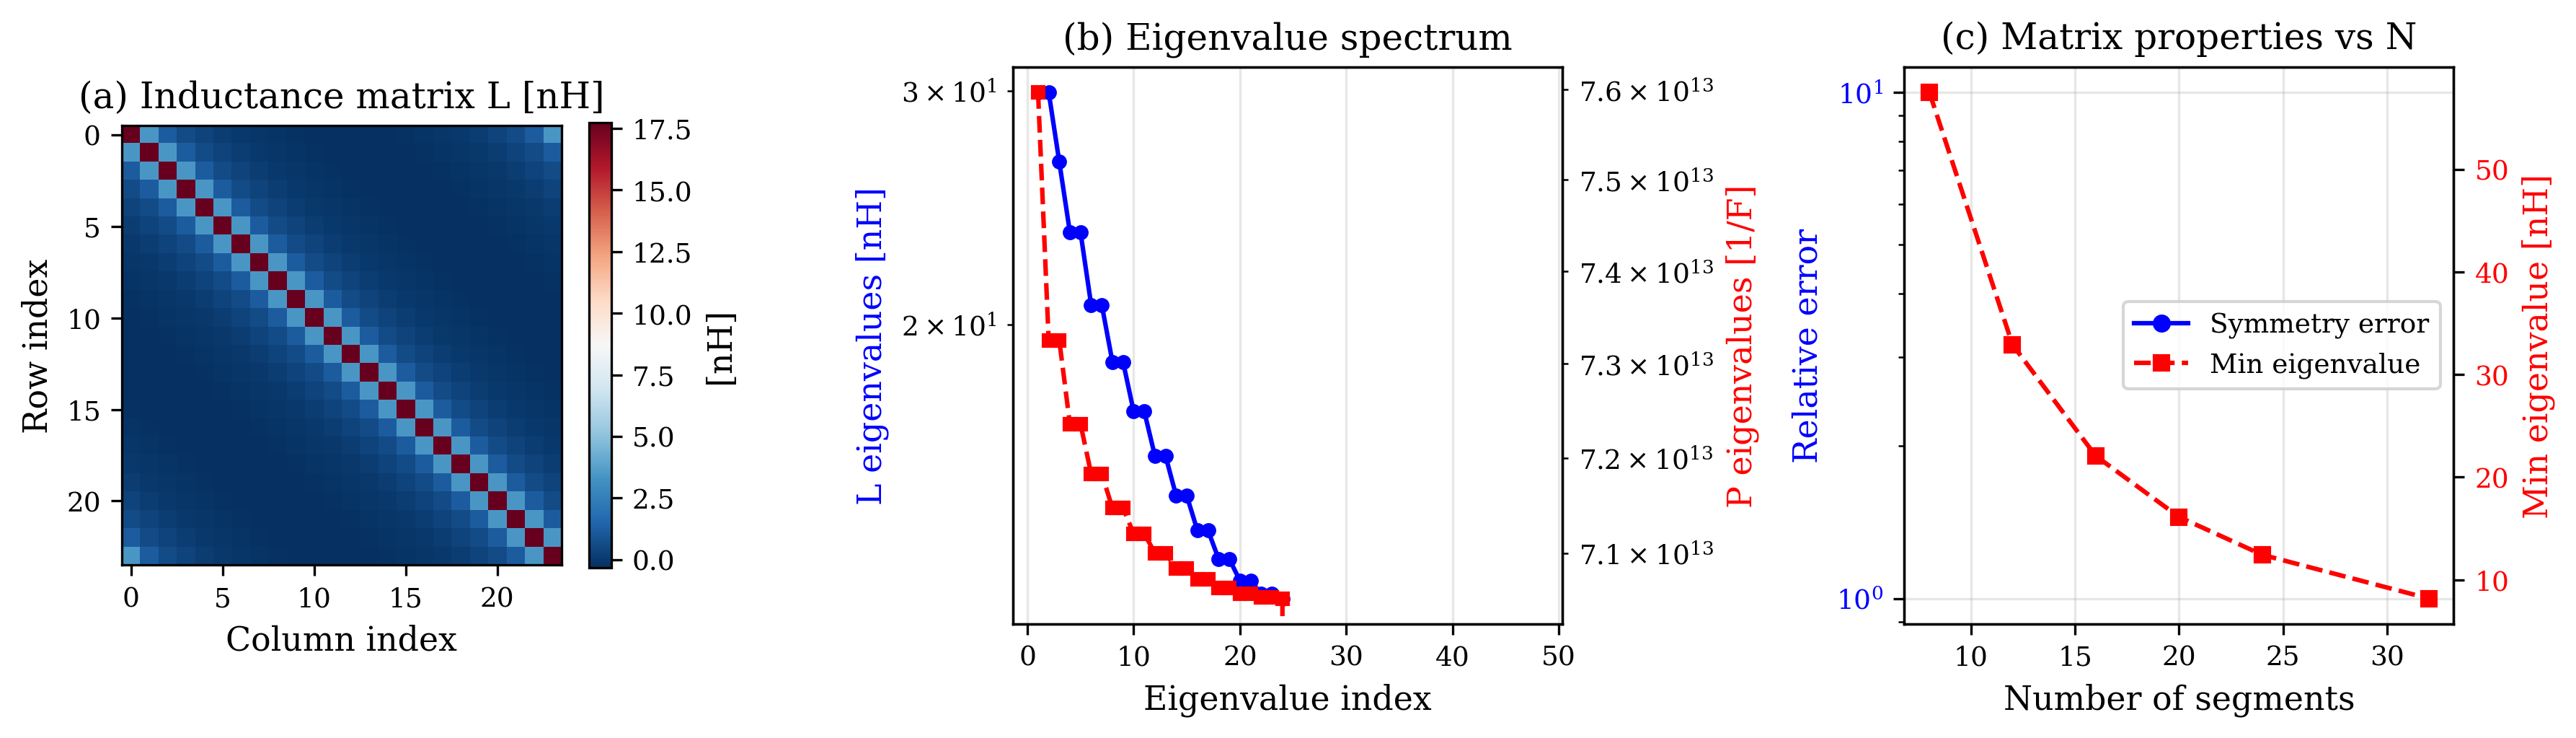

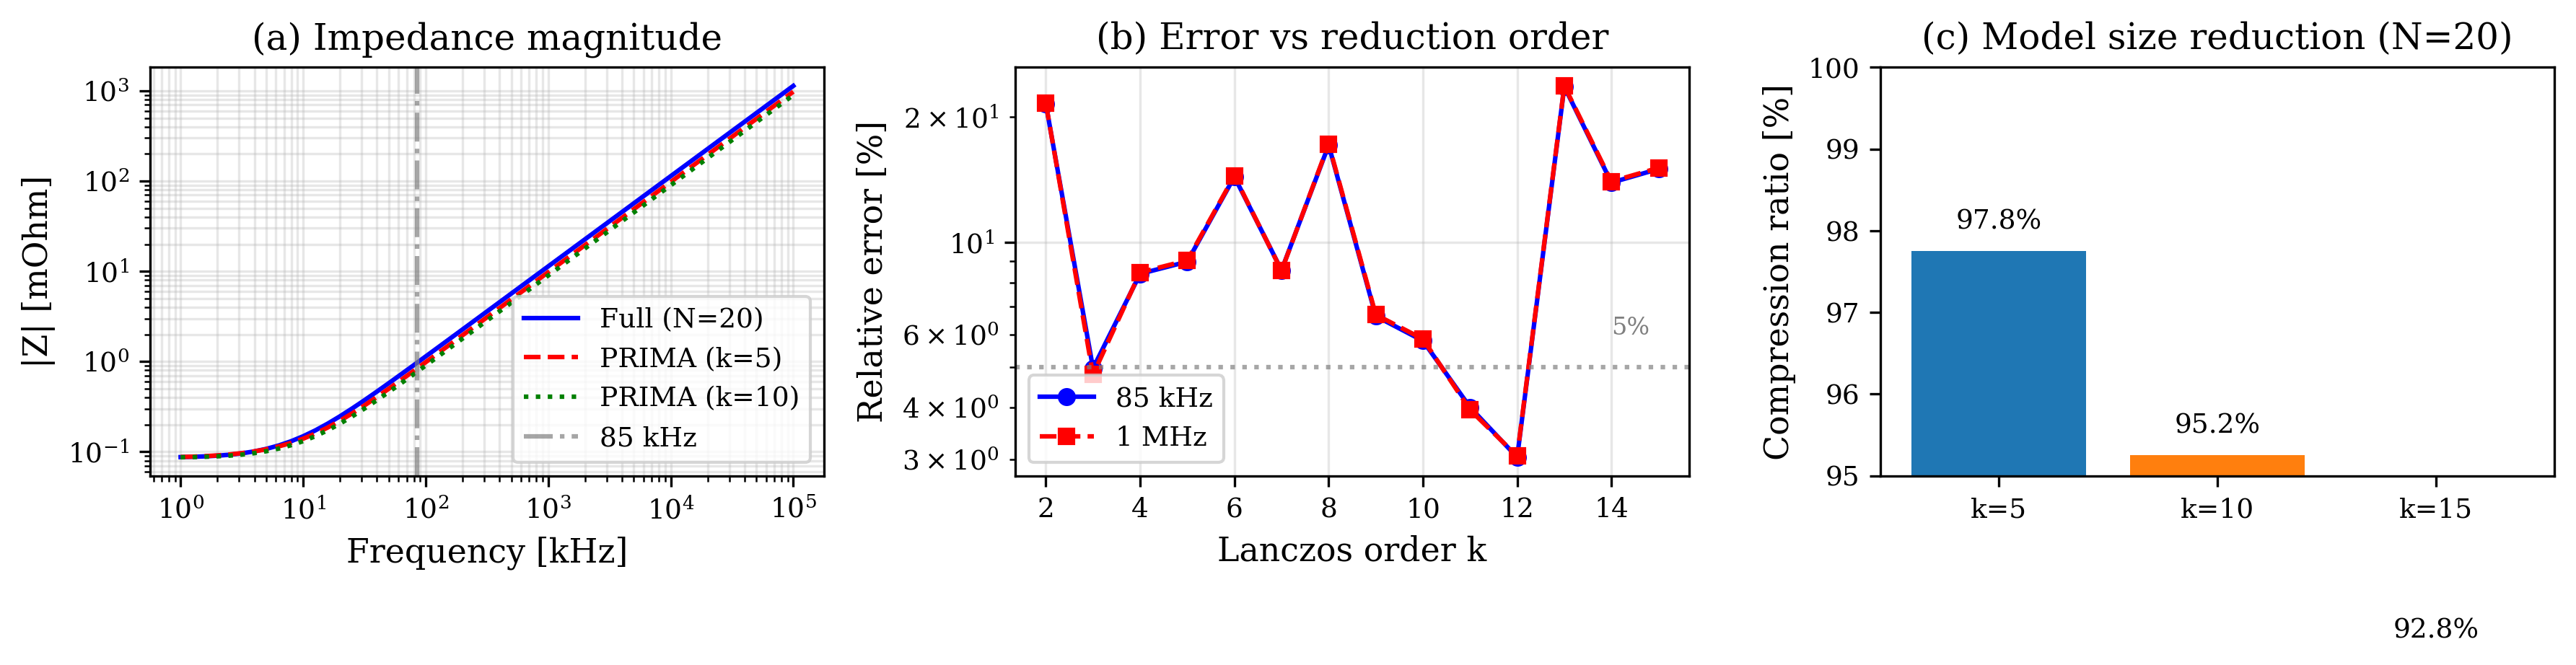

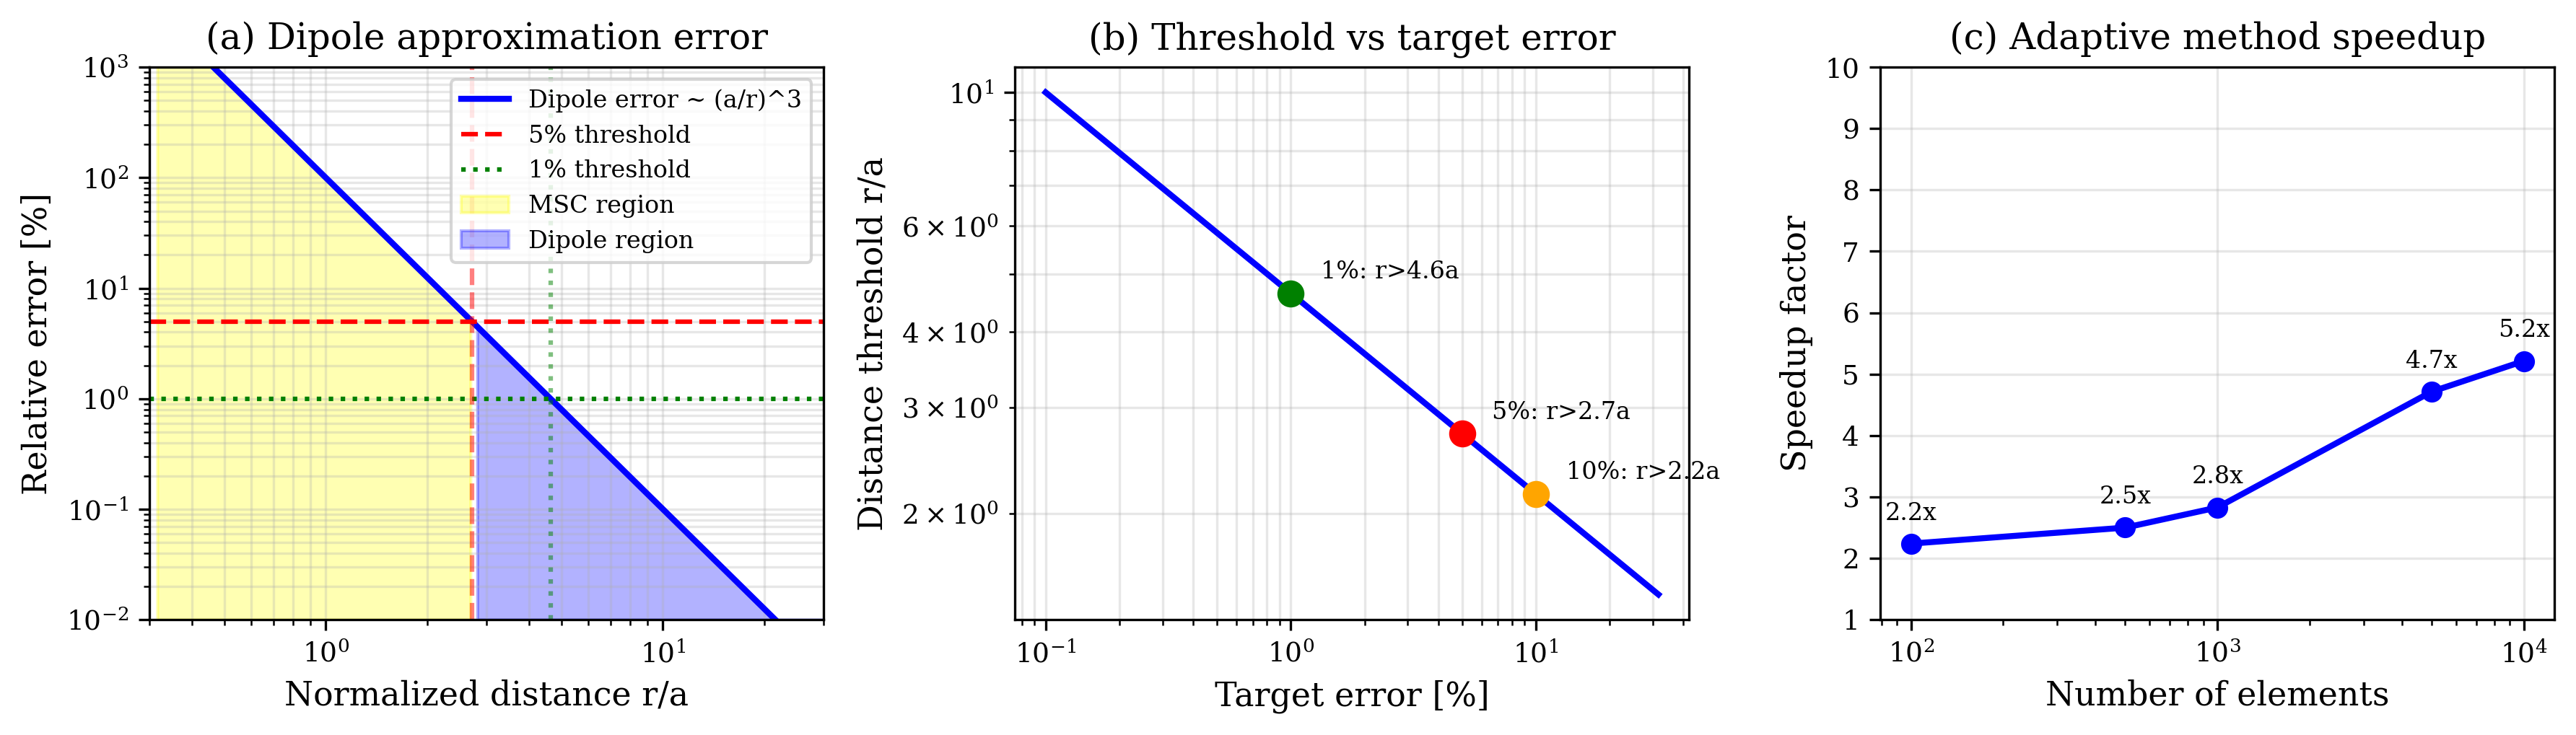

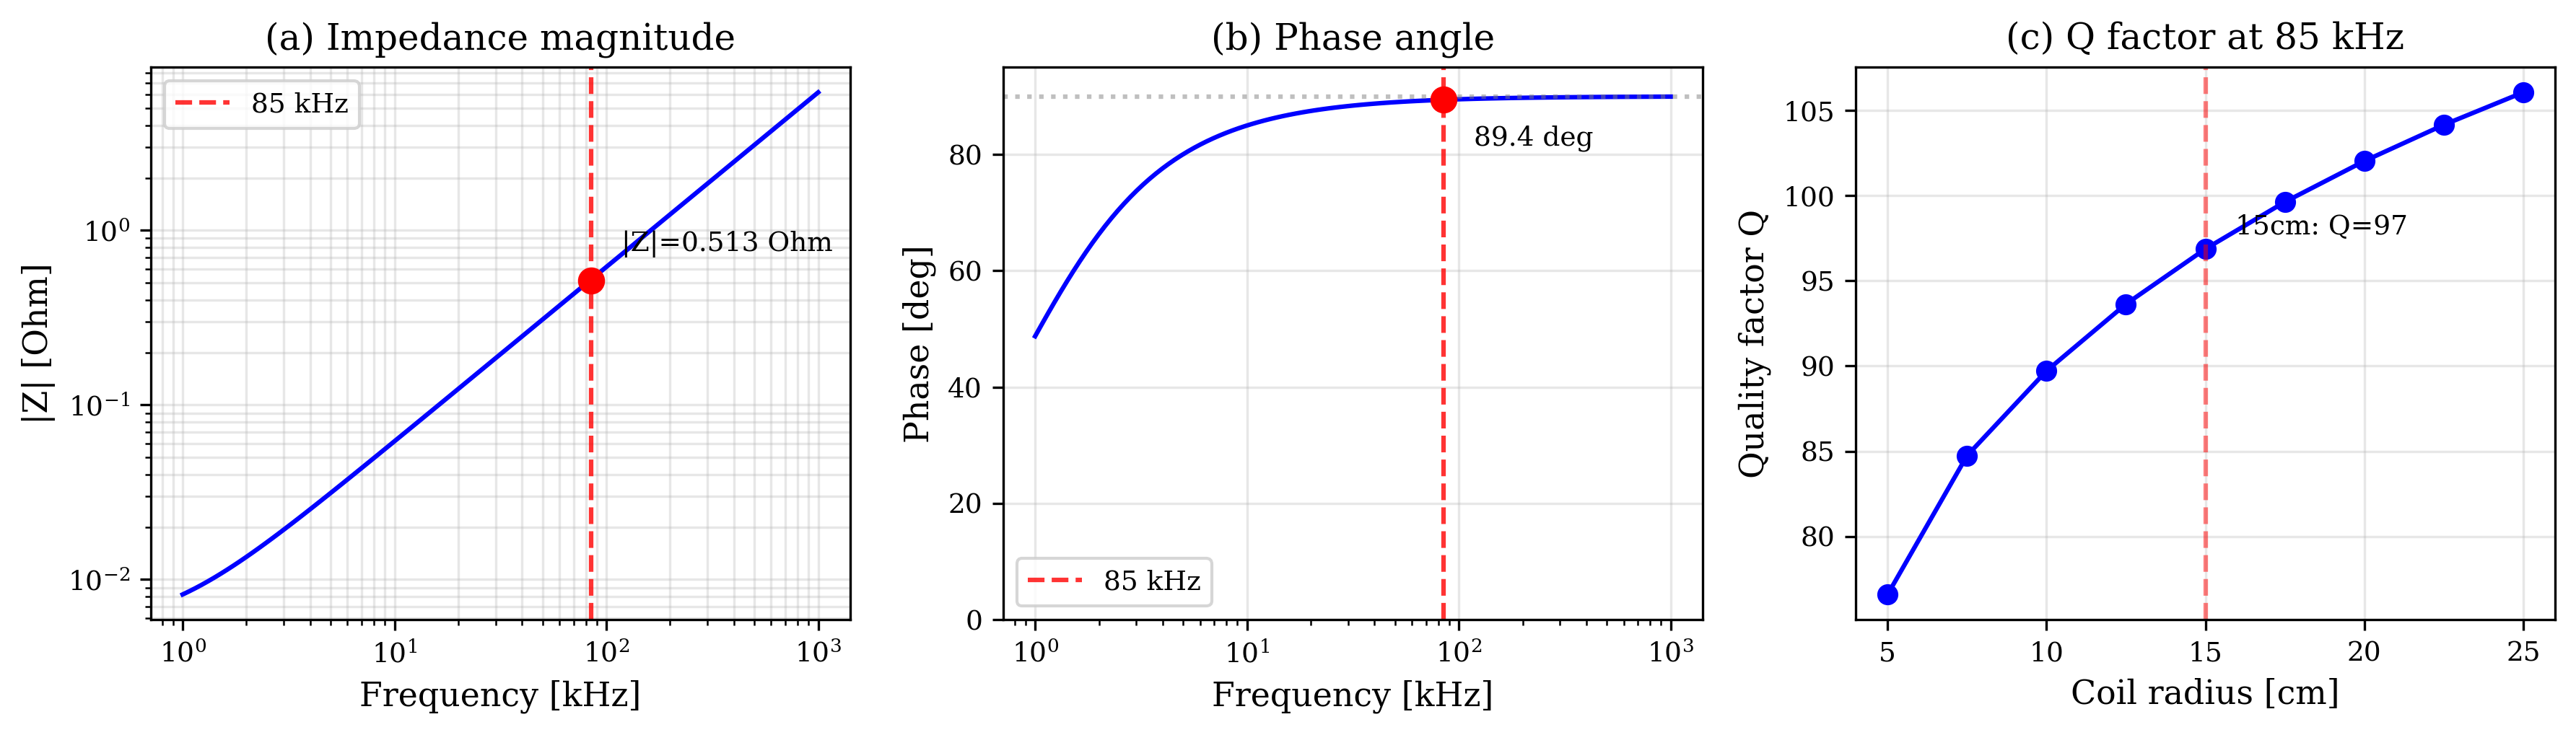

In [5]:
from IPython.display import Image, display
for f in ["figures/fig1_peec_matrix_verification.png", "figures/fig2_prima_accuracy.png",
          "figures/fig3_adaptive_msc_error.png", "figures/fig4_wpt_coil_85khz.png"]:
    try:
        display(Image(f))
    except Exception as e:
        print(f"({f}: {e})")